**UPLOAD THE FILE**

In [ ]:
import pandas as pd
df = pd.read_csv('/content/DATASET 1.csv')
df.head()

,NAT_590G>A,NAT_857G>A,NAT_481C>T,NAT_803A>G,NQO1_609C>T,SULT1A1_638G>A,EPMX1_337T>C,EPHX1_415A>G,CLASS,SEX,AGE,SMOKING,PACK YEARS,Histology
0,M,H,W,M,W,W,W,H,1,0,70,0,50.0,ADCC
1,H,W,W,H,W,W,H,H,0,0,75,0,17.5,NC
2,M,H,H,W,W,H,H,H,1,0,52,0,50.0,ADCC
3,H,H,H,H,H,W,H,W,0,0,42,0,24.0,NC
4,H,W,M,W,W,W,M,W,1,0,60,0,137.5,SCLC


**CHECK MISSING VALUES**

In [ ]:
df.isnull().sum()

,0
NAT_590G>A,0
NAT_857G>A,0
NAT_481C>T,0
NAT_803A>G,0
NQO1_609C>T,0
SULT1A1_638G>A,0
EPMX1_337T>C,0
EPHX1_415A>G,0
CLASS,0
SEX,0


**STANDARD SCALING**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['AGE', 'PACK YEARS']] = scaler.fit_transform(df[['AGE', 'PACK YEARS']])

**ENCODING SNPS COLUMNS**

In [ ]:
snp_cols = [
    'NAT_590G>A', 'NAT_857G>A', 'NAT_481C>T', 'NAT_803A>G',
    'NQO1_609C>T', 'SULT1A1_638G>A', 'EPMX1_337T>C', 'EPHX1_415A>G'
]
mapping = {'W': 0, 'H': 1, 'M': 2}
df = df.replace(mapping)
df.head()

/tmp/ipykernel_2987/1914876139.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


,NAT_590G>A,NAT_857G>A,NAT_481C>T,NAT_803A>G,NQO1_609C>T,SULT1A1_638G>A,EPMX1_337T>C,EPHX1_415A>G,CLASS,SEX,AGE,SMOKING,PACK YEARS,Histology
0,2,1,0,2,0,0,0,1,1,0,1.018553,0,1.248830,ADCC
1,1,0,0,1,0,0,1,1,0,0,1.476086,0,-0.131543,NC
2,2,1,1,0,0,1,1,1,1,0,-0.628568,0,1.248830,ADCC
3,1,1,1,1,1,0,1,0,0,0,-1.543635,0,0.144532,NC
4,1,0,2,0,0,0,2,0,1,0,0.103486,0,4.965219,SCLC


**REMOVE HISTOLOGY**

In [ ]:
df = df.drop('Histology', axis=1)

**REMOVE OUTLIERS**

In [ ]:
cols = ['AGE', 'PACK YEARS']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

**APPLY RANDOM FOREST MODEL**

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('CLASS', axis=1)
y = df['CLASS']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.631578947368421
              precision    recall  f1-score   support

           0       0.64      0.63      0.64       107
           1       0.62      0.64      0.63       102

    accuracy                           0.63       209
   macro avg       0.63      0.63      0.63       209
weighted avg       0.63      0.63      0.63       209



**HYPERTUNING OF RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,   # increase to 20 if time ho
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Best CV Score: 0.644311377245509
Test Accuracy: 0.5980861244019139
              precision    recall  f1-score   support

           0       0.62      0.56      0.59       107
           1       0.58      0.64      0.61       102

    accuracy                           0.60       209
   macro avg       0.60      0.60      0.60       209
weighted avg       0.60      0.60      0.60       209



**APPLY CATBOOST MODEL**

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
cb = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    verbose=0
)
cb.fit(X_train, y_train)
y_pred = cb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6267942583732058
              precision    recall  f1-score   support

           0       0.66      0.56      0.61       107
           1       0.60      0.70      0.65       102

    accuracy                           0.63       209
   macro avg       0.63      0.63      0.63       209
weighted avg       0.63      0.63      0.63       209



**HYPERTUNING OF CATBOOST**

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
cb = CatBoostClassifier(verbose=0)
param_dist = {
    'iterations': [200, 300, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7]
}
random_search = RandomizedSearchCV(
    cb,
    param_distributions=param_dist,
    n_iter=10,   # fast tuning
    cv=5,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
best_cb = random_search.best_estimator_
y_pred = best_cb.predict(X_test)
print("Best Params:", random_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 6}
Accuracy: 0.6555023923444976
              precision    recall  f1-score   support

           0       0.69      0.59      0.64       107
           1       0.63      0.73      0.67       102

    accuracy                           0.66       209
   macro avg       0.66      0.66      0.65       209
weighted avg       0.66      0.66      0.65       209



**APPLY XGBOOST MODEL**

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:42:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.645933014354067
              precision    recall  f1-score   support

           0       0.67      0.62      0.64       107
           1       0.63      0.68      0.65       102

    accuracy                           0.65       209
   macro avg       0.65      0.65      0.65       209
weighted avg       0.65      0.65      0.65       209



**HYPERTUNING OF XGBOOST**

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=15,   # fast (increase to 20 if time ho)
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:42:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV Score: 0.644311377245509
Test Accuracy: 0.6363636363636364
              precision    recall  f1-score   support

           0       0.65      0.62      0.63       107
           1       0.62      0.66      0.64       102

    accuracy                           0.64       209
   macro avg       0.64      0.64      0.64       209
weighted avg       0.64      0.64      0.64       209



**APPLY GRADIENT BOOSTING CLASSIFIER**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6172248803827751
              precision    recall  f1-score   support

           0       0.64      0.57      0.60       107
           1       0.60      0.67      0.63       102

    accuracy                           0.62       209
   macro avg       0.62      0.62      0.62       209
weighted avg       0.62      0.62      0.62       209



**HYPERTUNING OF GRADIENT BOOSTING CLASSIFIER**

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.05}
Best CV Score: 0.6407185628742516
Test Accuracy: 0.6794258373205742
              precision    recall  f1-score   support

           0       0.70      0.64      0.67       107
           1       0.66      0.72      0.69       102

    accuracy                           0.68       209
   macro avg       0.68      0.68      0.68       209
weighted avg       0.68      0.68      0.68       209



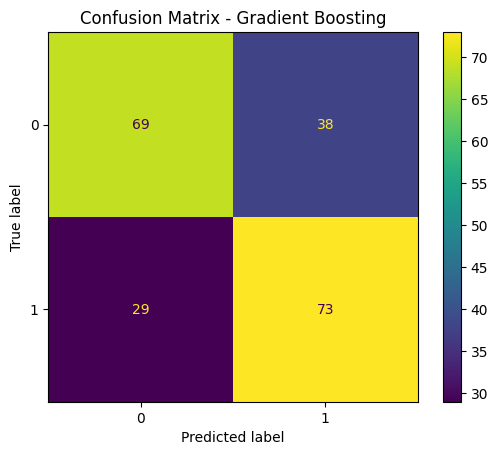

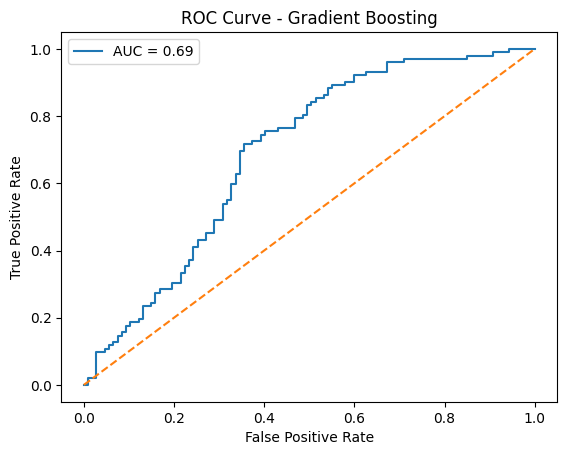

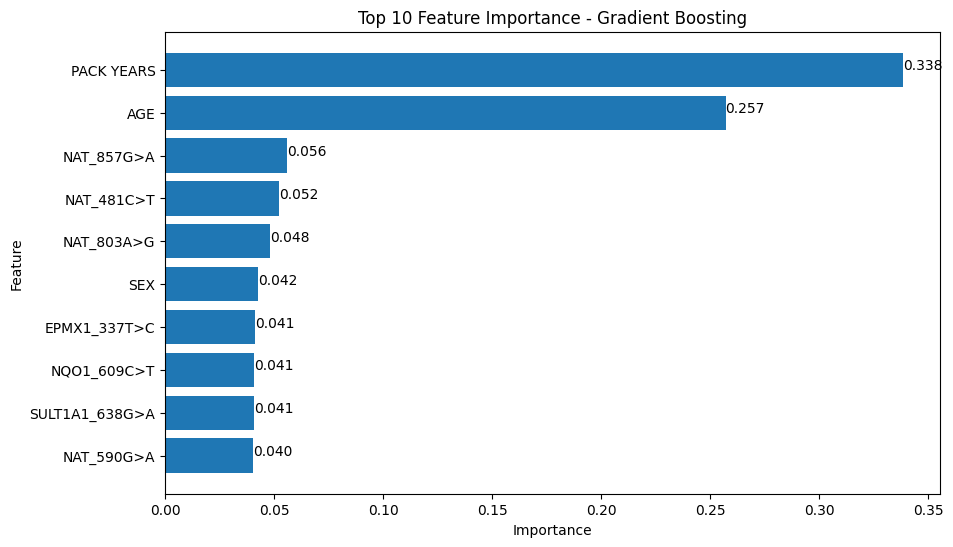

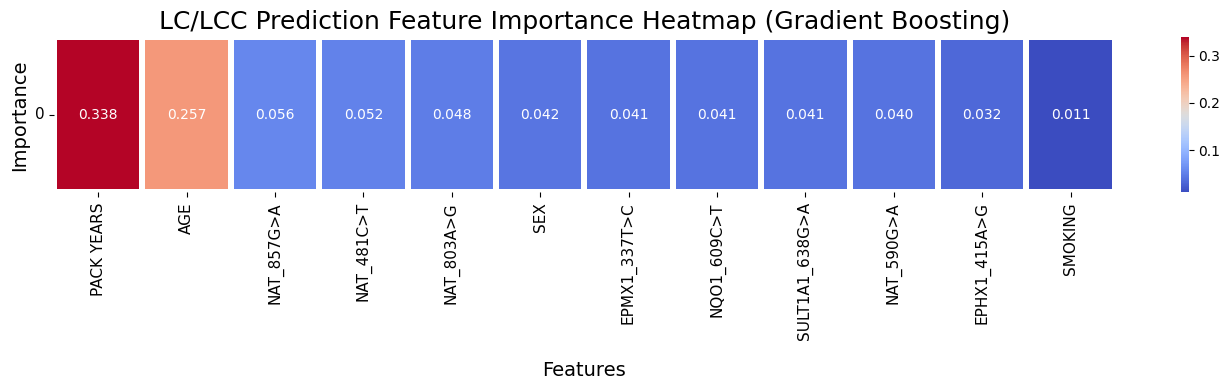

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
gb = GradientBoostingClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random_search = RandomizedSearchCV(
    gb,
    param_distributions=param_dist,
    n_iter=15,   # fast (increase to 20 if time ho)
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)
best_gb = random_search.best_estimator_
y_pred = best_gb.predict(X_test)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

from sklearn.metrics import roc_curve, auc

# Probability prediction
y_prob = best_gb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

import seaborn as sns
import pandas as pd

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 features
top10 = feature_importance.head(10)

# Plot horizontal bar graph
plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

# Highest value on top
plt.gca().invert_yaxis()

# Add values on bars
for i, v in enumerate(top10['Importance']):
    plt.text(v, i, f"{v:.3f}")

# Labels and title
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Gradient Boosting")

plt.show()

# Feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
})

# Convert feature names into CAPITALS
feature_importance['Feature'] = feature_importance['Feature'].str.upper()

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 12 features
top_features = feature_importance.head(12)

# Convert into single-row dataframe
heatmap_data = pd.DataFrame(
    [top_features['Importance'].values],
    columns=top_features['Feature']
)

# Plot Heatmap
plt.figure(figsize=(14, 4))

sns.heatmap(
    heatmap_data,

    annot=True,
    fmt=".3f",

    cmap='coolwarm',

    linewidths=3,
    linecolor='white',

    cbar=True,

    annot_kws={
        "size": 10,
        "color": "white"
    }
)

# Title and labels
plt.title(
    "LC/LCC Prediction Feature Importance Heatmap (Gradient Boosting)",
    fontsize=18
)

plt.xlabel(
    "Features",
    fontsize=14,
    labelpad=15
)

plt.ylabel(
    "Importance",
    fontsize=14
)

# Tick formatting
plt.xticks(
    rotation=90,
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

plt.tight_layout()

plt.show()

**APPLY SUPPORT VECTOR MACHINE**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm = SVC(
    kernel='rbf',   # best default
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6507177033492823
              precision    recall  f1-score   support

           0       0.67      0.64      0.65       107
           1       0.64      0.67      0.65       102

    accuracy                           0.65       209
   macro avg       0.65      0.65      0.65       209
weighted avg       0.65      0.65      0.65       209



**APPLY HYPERTUNING OF SUPPORT VECTOR MACHINE**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm = SVC(probability=True, random_state=42)
param_dist = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}
random_search = RandomizedSearchCV(
    svm,
    param_distributions=param_dist,
    n_iter=10,   # fast
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train_scaled, y_train)
best_svm = random_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}
Best CV Score: 0.62874251497006
Test Accuracy: 0.6507177033492823
              precision    recall  f1-score   support

           0       0.67      0.64      0.65       107
           1       0.64      0.67      0.65       102

    accuracy                           0.65       209
   macro avg       0.65      0.65      0.65       209
weighted avg       0.65      0.65      0.65       209



**APPLY K-NEAREST NEIGHBORS MODEL**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(
    n_neighbors=5,   # default
    metric='minkowski',
    p=2   # Euclidean distance
)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5885167464114832
              precision    recall  f1-score   support

           0       0.59      0.65      0.62       107
           1       0.59      0.52      0.55       102

    accuracy                           0.59       209
   macro avg       0.59      0.59      0.59       209
weighted avg       0.59      0.59      0.59       209



**APPLY HYPERTUNING OF K-NEAREST NEIGHBORS MODEL**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier()
param_dist = {
    'n_neighbors': list(range(3, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
random_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=10,   # fast
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train_scaled, y_train)
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'weights': 'uniform', 'n_neighbors': 12, 'metric': 'euclidean'}
Best CV Score: 0.6107784431137724
Test Accuracy: 0.5885167464114832
              precision    recall  f1-score   support

           0       0.58      0.73      0.64       107
           1       0.61      0.44      0.51       102

    accuracy                           0.59       209
   macro avg       0.59      0.59      0.58       209
weighted avg       0.59      0.59      0.58       209



**APPLY GAUSSIAN NAIVE BAYES MODEL**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5885167464114832
              precision    recall  f1-score   support

           0       0.59      0.66      0.62       107
           1       0.59      0.51      0.55       102

    accuracy                           0.59       209
   macro avg       0.59      0.59      0.59       209
weighted avg       0.59      0.59      0.59       209



**APPLY HYPERTUNING OF GAUSSIAN NAIVE BAYES MODEL**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
gnb = GaussianNB()
param_grid = {
    'var_smoothing': np.logspace(-9, -1, 50)
}
grid = GridSearchCV(
    gnb,
    param_grid,
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_gnb = grid.best_estimator_
y_pred = best_gnb.predict(X_test)
print("Best Parameter:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameter: {'var_smoothing': np.float64(0.02222996482526191)}
Best CV Score: 0.5688622754491017
Test Accuracy: 0.583732057416268
              precision    recall  f1-score   support

           0       0.58      0.66      0.62       107
           1       0.59      0.50      0.54       102

    accuracy                           0.58       209
   macro avg       0.58      0.58      0.58       209
weighted avg       0.58      0.58      0.58       209




**APPLY LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5933014354066986
              precision    recall  f1-score   support

           0       0.60      0.64      0.62       107
           1       0.59      0.55      0.57       102

    accuracy                           0.59       209
   macro avg       0.59      0.59      0.59       209
weighted avg       0.59      0.59      0.59       209



**APPLY HYPERTUNING OF LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr = LogisticRegression(max_iter=1000, random_state=42)
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']   # supports both l1 & l2
}
random_search = RandomizedSearchCV(
    lr,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train_scaled, y_train)
best_lr = random_search.best_estimator_
y_pred = best_lr.predict(X_test_scaled)
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 1}
Best CV Score: 0.5736526946107785
Test Accuracy: 0.5933014354066986
              precision    recall  f1-score   support

           0       0.60      0.64      0.62       107
           1       0.59      0.55      0.57       102

    accuracy                           0.59       209
   macro avg       0.59      0.59      0.59       209
weighted avg       0.59      0.59      0.59       209



**ROC CURVE FOR HYPERTUNED MODELS**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


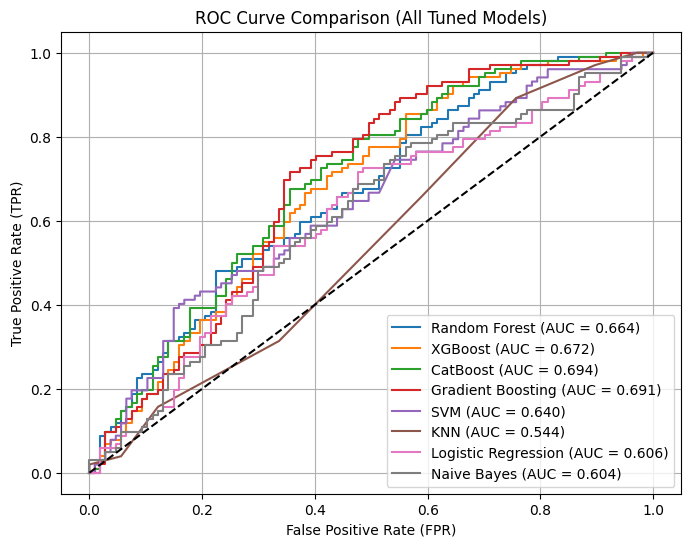

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "CatBoost": best_cb,
    "Gradient Boosting": best_gb,
    "SVM": best_svm,
    "KNN": best_knn,
    "Logistic Regression": best_lr,
    "Naive Bayes": best_gnb
}

plt.figure(figsize=(8,6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison (All Tuned Models)")
plt.legend()
plt.grid()

plt.show()

**ALL HYPERTUNED MODELS ACCURACY TOGETHER**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score
models = {
    "CatBoost": best_cb,
    "XGBoost": best_xgb,
    "Gradient Boosting": best_gb,
    "Random Forest": best_rf,
    "SVM": best_svm,
    "KNN": best_knn,
    "Naive Bayes": best_gnb,
    "Logistic Regression": best_lr
}
results = []

for name, model in models.items():
    if name == "SVM":
        y_pred = model.predict(X_test_scaled)
    elif name == "KNN" or name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])
df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
df_results = df_results.sort_values(by="Accuracy", ascending=False)
print(df_results)

                 Model  Accuracy
2    Gradient Boosting  0.679426
0             CatBoost  0.655502
4                  SVM  0.650718
1              XGBoost  0.636364
3        Random Forest  0.598086
7  Logistic Regression  0.593301
5                  KNN  0.588517
6          Naive Bayes  0.583732


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store all models
models = {
    "CatBoost": best_cb,
    "XGBoost": best_xgb,
    "Gradient Boosting": best_gb,
    "Random Forest": best_rf,
    "Support Vector Machine": best_svm,
    "K-Nearest Neighbors": best_knn,
    "Gaussian Naive Bayes": best_gnb,
    "Logistic Regression": best_lr
}

results = []

# Loop through all models
for name, model in models.items():

    # Scaled data for SVM, KNN, Logistic Regression
    if name in ["Support Vector Machine", "K-Nearest Neighbors", "Logistic Regression"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Metrics calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Append results
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

# Round values to 3 decimal places
df_results = df_results.round(3)

# Sort by Accuracy
df_results = df_results.sort_values(by="Accuracy", ascending=False)

# Reset index
df_results.reset_index(drop=True, inplace=True)

# Display table
print(df_results.to_string(index=False))

                 Model  Accuracy  Precision  Recall  F1-score
     Gradient Boosting     0.679      0.681   0.679     0.679
              CatBoost     0.656      0.660   0.656     0.654
Support Vector Machine     0.651      0.651   0.651     0.651
               XGBoost     0.636      0.637   0.636     0.636
         Random Forest     0.598      0.600   0.598     0.598
   Logistic Regression     0.593      0.593   0.593     0.593
   K-Nearest Neighbors     0.589      0.593   0.589     0.580
  Gaussian Naive Bayes     0.584      0.584   0.584     0.581
